## Trabajo Práctico $\mathbb{II}$

Inferencia y Estimación

---

#### Imports y Variables Globales

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
from collections import OrderedDict
from huffman_code import huffman_code # código provisto por la cátedra

filepath = Path('text_examples') 
figures_path = '../report/figures/'

example_strings_name = [] # lista con los nombres de los textos de ejemplo
example_strings = [] # lista con los textos de ejemplo
for file in filepath.glob('*.txt'):
    example_strings_name.append(file.name)
    with file.open('r', encoding='utf-8') as f:
        example_strings.append(f.read())

---

#### $\boldsymbol{(1)}$ $p(x):$ masa de probabilidad de caracteres

In [2]:
def character_pmf(txt: str) -> OrderedDict[str|float]:
    ''' Dado una cadena de texto devuelve un diccionario representando la masa de probabilidad de cada caracter en la cadena
    Args:
        txt (str): cadena de texto
    Returns:
        pmf (dict[str|float]): masa de probabilidad estimada
    '''
    n = len(txt)
    pmf = OrderedDict()
    for c in txt.strip():
        c = c.lower() # tomamos mayúscula y minúscula ACLARAR EN EL INFORME
        if c not in pmf and c:
            pmf[c] = 1/n
        else:
            pmf[c] += 1/n
    return pmf

def pmf_chart(pmf : OrderedDict, fig: plt.Figure = None, idx: int = None, color: str = None, file_name: str = None) -> None:
    ''' A partir de la masa de probabilidad estimada para los caracteres de un string, realiza un gráfico de barras con la frecuencia
    de cada caracter en ordern descendente según la frecuencia.
    Args:
        pmf (dict): representación de la masa de probabilidad {char : frequency}
        fig (plt.figure.Figure): objeto figura de matplotlib en donde se creará el subplot
        idx (int): entero de 3 dígitos que representa el índice del subplot a agregar ('row' 'collumn' 'index')
    '''
    pmf = OrderedDict(sorted(pmf.items(), key=lambda x: x[1], reverse=True)) # ordenar el diccionario en orden descendente según la probabilidad de cada caracter
    if fig is None: fig = plt.figure(figsize=(10,6))
    if idx is None: idx = 111
    if color is None: color = 'b'
    ax = fig.add_subplot(idx)
    ax.bar(pmf.keys(), pmf.values(), color=color, edgecolor='black')
    if file_name is not None:
        ax.set_title(file_name, fontsize=20)
    ax.set_ylabel('frequency', fontsize=16)
    ax.tick_params(axis='both', which='both', labelsize=16)
    ax.grid(axis='y')

Resultado para los textos de ejemplo

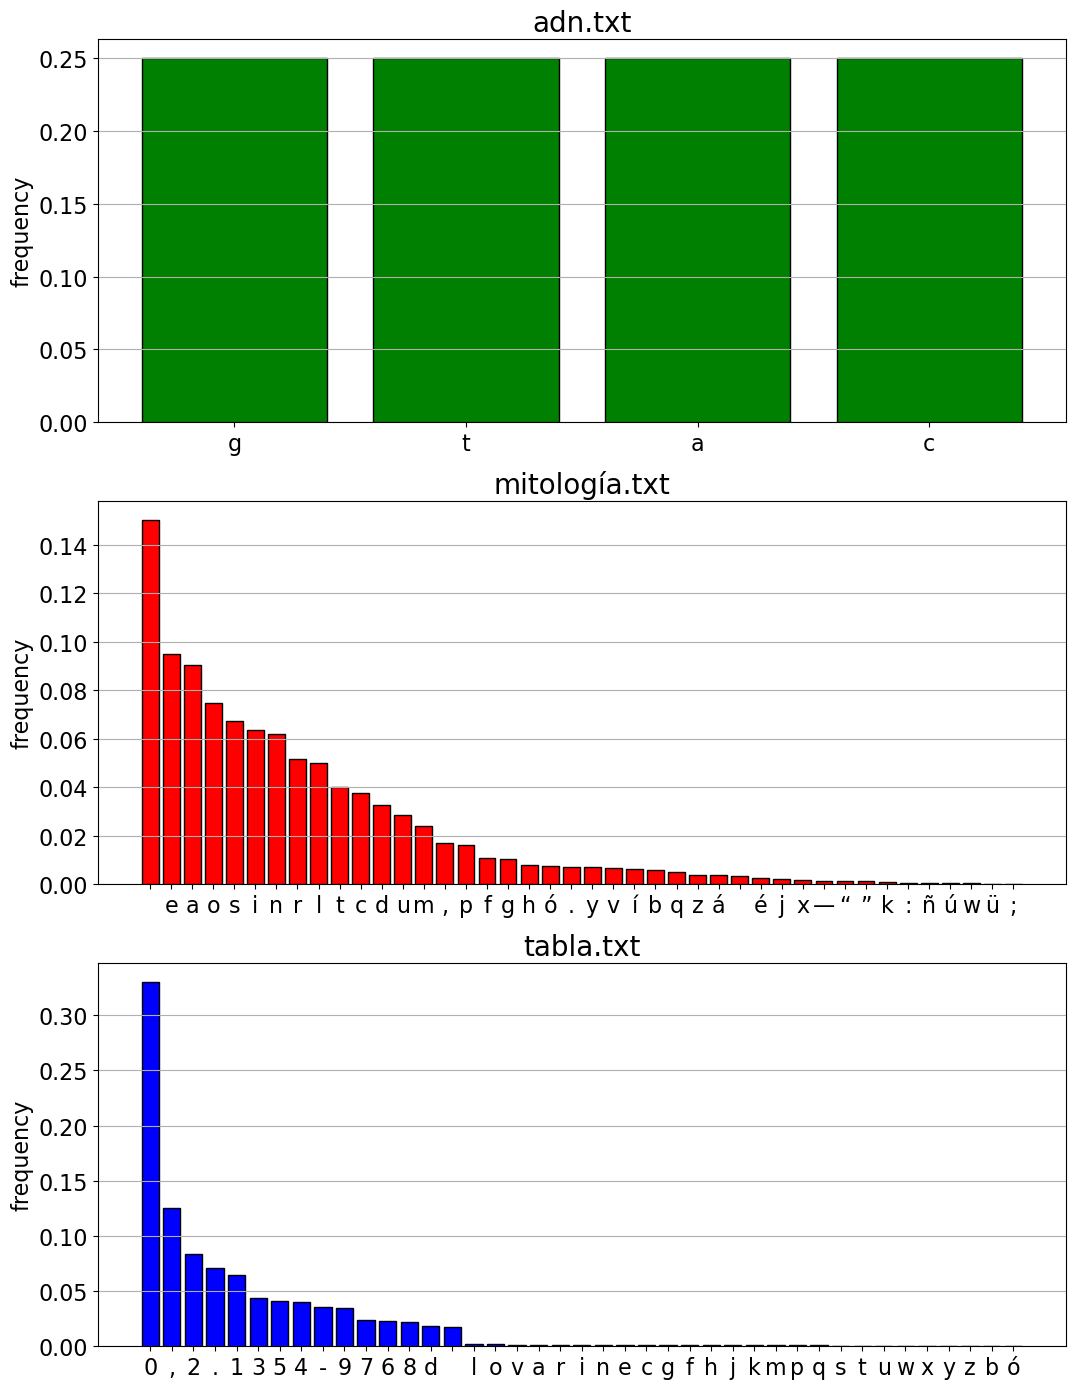

In [3]:
fig = plt.figure(figsize=(11,14))
idx = 311
colors = ['blue', 'red', 'green']
for file, string in zip(example_strings_name, example_strings):
    pmf = character_pmf(string)
    pmf_chart(pmf, fig, idx, colors.pop(), file)
    idx += 1
plt.tight_layout()
plt.savefig(figures_path + 'character_pmf.png')
plt.show()

#### $\boldsymbol{(2)}$ Codificación de Huffman

#### ***Definición de Longitud Promedio***: 

Dado un alfabeto de una fuente $\mathbf{X}$ con $N$ símbolos únicos $\mathbf{X}=\{x_1,x_2,\dots,x_N\}$, donde cada símbolo $x_i$ tiene probabilidad $p(x_i)$ y se le asigna un código binario de longitud $\ell(x_i)$ bits, la longitud promedio $L$ se define como la esperanza de la longitud del código:

$$
L \;=\; \mathbb{E}\big[\ell(\mathbf{X})\big] \;=\; \sum_{i=1}^{N} p(x_i)\,\ell(x_i),
$$

sujeto a $\sum_{i=1}^{N} p(x_i)=1$.

- $L$: costo promedio en bits por símbolo (longitud media del código).



#### ***Definición: Cantidad de Bits para una Codificación Uniforme ($L_{\text{unif}}$)***

Si una fuente tiene $N$ símbolos únicos, necesitamos la menor cantidad entera de bits $k$ tal que se puedan formar al menos $N$ códigos binarios distintos. Como con $k$ bits se generan $2^{k}$ códigos, debe cumplirse:

$$
2^{k} \ge N
$$

Aplicando logaritmo en base 2 y tomando la función techo para obtener un entero:

$$
k \ge \log_{2}N \quad\Longrightarrow\quad L_{\text{unif}} = \left\lceil \log_{2} N \right\rceil
$$

Aquí $L_{\text{unif}}$ es la longitud uniforme mínima en bits por símbolo.


#### ***Definicion: Reducción de memoria (%)***

El porcentaje de reducción se calcula como la disminución fraccional en la longitud de bits, expresada como porcentaje. Aquí \(L\) es la longitud promedio (p. ej. Huffman) y \(L_{\text{unif}}\) la longitud uniforme mínima.

$$
\text{Reducción}(\%)=\frac{L_{\text{unif}}-L}{L_{\text{unif}}}\times 100
=\left(1-\frac{L}{L_{\text{unif}}}\right)\times 100
$$


In [4]:
pmfs = [character_pmf(s) for s in example_strings] # vector de pmf de cada texto
huffman_codes = [huffman_code(pmf) for pmf in pmfs] # vector de codigos de huffman para cada pmf
symbol_amount = []
average_length = []
uniform_length = []
memory_reduction = []

for i, name in enumerate(example_strings_name): 
	pmf = pmfs[i]
	huff_code = huffman_codes[i]

	# Parte (a): Longitud Promedio de Bits
	huffman_average_long = 0
	for char, prob in pmf.items():
		huffman_average_long += prob * len(huff_code[char])

	# Parte (b): Longitud de Bits para Codificacion Uniforme
	n_symbol = len(pmf)
	unif_length = np.ceil(np.log2(n_symbol))

	# Parte (c): Porcentaje de reduccion
	reduction = abs((1 - (huffman_average_long / unif_length)) * 100)
	
	symbol_amount.append(n_symbol)
	average_length.append(huffman_average_long)
	uniform_length.append(unif_length)
	memory_reduction.append(reduction)

    # Print de Resultados
	print(f"Resultados para '{name}':")
	print(f"  - Número de símbolos únicos (N): {n_symbol}")
	print(f"  - Longitud Promedio (Huffman): {huffman_average_long:.4f} [bits/simbolo]")
	print(f"  - Longitud Uniforme Mínima: {unif_length} [bits/simbolo]")
	print(f"  - Reducción de memoria: {reduction:.2f}%\n")

Resultados para 'adn.txt':
  - Número de símbolos únicos (N): 4
  - Longitud Promedio (Huffman): 2.0000 [bits/simbolo]
  - Longitud Uniforme Mínima: 2.0 [bits/simbolo]
  - Reducción de memoria: 0.00%

Resultados para 'mitología.txt':
  - Número de símbolos únicos (N): 42
  - Longitud Promedio (Huffman): 4.3013 [bits/simbolo]
  - Longitud Uniforme Mínima: 6.0 [bits/simbolo]
  - Reducción de memoria: 28.31%

Resultados para 'tabla.txt':
  - Número de símbolos únicos (N): 41
  - Longitud Promedio (Huffman): 3.5161 [bits/simbolo]
  - Longitud Uniforme Mínima: 6.0 [bits/simbolo]
  - Reducción de memoria: 41.40%



#### $\boldsymbol{(3)}$ $H(X):$ Entropía de los textos

In [5]:
def entropy(prob:dict):
    output = 0
    for char in prob.keys():
        p = prob[char]
        output += p*np.log2(p)
    return -output        

#### $\boldsymbol{(4)}$ $\eta:$ Entropía normalizada

$$
\eta = \frac{H(X)}{\log_2(N)}, \quad {\small N: \text{cantidad de símbolos}}
$$

In [6]:
def norm_entropy(prob:dict):
    return entropy(prob)/np.log2(len(list(prob.keys())))

In [7]:
print('\tCOMPARACIÓN DE ENTROPÍAS')
h_list = []
eta_list = []
for i, (string, name) in enumerate(zip(example_strings, example_strings_name)):
    print(f"({i+1}) '{name}' ")
    pmf = character_pmf(string)
    h = entropy(pmf)
    h_list.append(h)
    eta = norm_entropy(pmf)
    eta_list.append(eta)
    print(f'\t- H(X) : {h:.6f}')
    print(f'\t- η(X) : {eta:.6f}')

	COMPARACIÓN DE ENTROPÍAS
(1) 'adn.txt' 
	- H(X) : 1.999999
	- η(X) : 1.000000
(2) 'mitología.txt' 
	- H(X) : 4.268560
	- η(X) : 0.791600
(3) 'tabla.txt' 
	- H(X) : 3.466877
	- η(X) : 0.647101


#### Cuadro comparativo para todos los textos

In [19]:
# Organización de los datos
labels = ['Archivo', 'Entropía', 'Entropía Normalizada', 'Cantidad de Símbolos', 'Longitud Promedio', 'Longitud Uniforme Mínima', 'Reducción de Memoria']
data = [example_strings_name, h_list, eta_list, symbol_amount, average_length, uniform_length, memory_reduction]
units = {
    "Entropía": "[bits/symbol]",
    "Entropía Normalizada": "[bits]",
    "# de Símbolos": "[count]",
    "Longitud Promedio": "[bits/symbol]",
    "Longitud Uniforme Mínima": "[bits/symbol]",
    "Reducción de Memoria": "[%]"
}
# Creación del DataFrame
df = pd.DataFrame()
for label, collumn in zip(labels[::-1], data[::-1]):
    df.insert(0, label, collumn)
    
# Agrega una fila en los índices para las unidades
df.columns = pd.MultiIndex.from_tuples([(col, units.get(col, "")) for col in df.columns])

# Formateo de la Tabla
df = (
    df.style
		.format(precision=6)
		.set_caption('Resumen de Datos para los textos de ejemplo')
		.set_table_styles([
			{"selector": "caption",
			"props": [("font-size", "18pt"), ("font-weight", "bold"), ("text-align", "center"), ("padding", "6px")]},
			# head
			{"selector": "th.col_heading",
			"props": [("font-size", "15pt"), ("font-weight", "600"), ("text-align", "center")]},
			# unidades
			{"selector": "th.col_heading.level1",
			"props": [("font-size", "10pt"), ("font-weight", "400")]}, 
			# celdas
			{"selector": "td", 
			"props": [("font-size", "14pt"), ("text-align", "center")]},
		])
)
df

,Archivo,Entropía,Entropía Normalizada,Cantidad de Símbolos,Longitud Promedio,Longitud Uniforme Mínima,Reducción de Memoria
,,[bits/symbol],[bits],,[bits/symbol],[bits/symbol],[%]
0,adn.txt,1.999999,1.000000,4,2.000000,2.000000,0.000000
1,mitología.txt,4.268560,0.791600,42,4.301327,6.000000,28.311223
2,tabla.txt,3.466877,0.647101,41,3.516129,6.000000,41.397849


In [20]:
# Tabla a LaTeX para insertar en el informe
latex = df.to_latex()
print(latex)

\begin{table}
\caption{Resumen de Datos para los textos de ejemplo}
\th.col_heading15pt
\th.col_heading.level110pt
\td14pt
\begin{tabular}{llrrrrrr}
 & Archivo & Entropía & Entropía Normalizada & Cantidad de Símbolos & Longitud Promedio & Longitud Uniforme Mínima & Reducción de Memoria \\
 &  & [bits/symbol] & [bits] &  & [bits/symbol] & [bits/symbol] & [%] \\
0 & adn.txt & 1.999999 & 1.000000 & 4 & 2.000000 & 2.000000 & 0.000000 \\
1 & mitología.txt & 4.268560 & 0.791600 & 42 & 4.301327 & 6.000000 & 28.311223 \\
2 & tabla.txt & 3.466877 & 0.647101 & 41 & 3.516129 & 6.000000 & 41.397849 \\
\end{tabular}
\end{table}

